In [137]:
import pickle
from matplotlib import pyplot as plt
import numpy as np

In [138]:
with open('../data/consolitdation.pkl', 'rb') as f:
    consolidation = pickle.load(f)

with open('../data/remapping.pkl', 'rb') as f:
    remapping = pickle.load(f)

    

In [139]:
place_field_shift_consolidation = np.argmax(consolidation[0]['rate_avg'], axis=0) - np.argmax(consolidation[1]['rate_avg'], axis=0)
place_field_shift_remapping = np.argmax(remapping[0]['rate_avg'], axis=0) - np.argmax(remapping[1]['rate_avg'], axis=0)

v_data_place_filed_shifts = np.vstack([place_field_shift_consolidation, place_field_shift_remapping])
m1 = v_data_place_filed_shifts >= 50
v_data_place_filed_shifts[m1] -= 100
m2 = v_data_place_filed_shifts <= -50
v_data_place_filed_shifts[m2] += 100

In [172]:
mosaic = """
    AABBCC
    DDDEEE
    FFFGGG
    """

place_filed_tiles = ['A', 'B', 'C']
titles = ['Mapping', 'Consolidation', 'Mapping', 'Remapping']



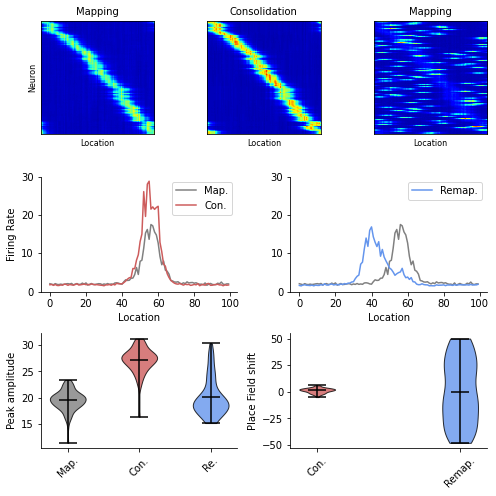

In [183]:
#fig = plt.figure(layout="constrained")
fig = plt.figure(figsize=(7,7))

ax_dict = fig.subplot_mosaic(mosaic)

vmin = 0
vmax = 35
cmap = 'jet'

ax_dict['A'].imshow(consolidation[0]['rate_avg'].T[consolidation[0]['sorting']], vmin=vmin, vmax=vmax, cmap=cmap)
ax_dict['B'].imshow(consolidation[1]['rate_avg'].T[consolidation[0]['sorting']], vmin=vmin, vmax=vmax, cmap=cmap)
#ax_dict['B'].imshow(remapping[0]['rate_avg'].T[remapping[0]['sorting']], vmin=vmin, vmax=vmax, cmap=cmap)
ax_dict['C'].imshow(remapping[1]['rate_avg'].T[remapping[0]['sorting']], vmin=vmin, vmax=vmax, cmap=cmap)


for tile in place_filed_tiles:

    ax_dict[tile].set_xticks([])
    ax_dict[tile].set_yticks([])

    ax_dict[tile].set_xlabel('Location', fontsize=8)

ax_dict['A'].set_ylabel('Neuron', fontsize=8)

for (tile, title) in zip(place_filed_tiles, titles):
    ax_dict[tile].set_title(title, fontsize=10)

ax_dict['A'].set_ylabel('Neuron')


ax_dict['D'].plot(consolidation[0]['rate_avg'].T[consolidation[0]['sorting']][50], c='grey', label='Map.')
ax_dict['D'].plot(consolidation[1]['rate_avg'].T[consolidation[0]['sorting']][50], c='indianred', label='Con.')
ax_dict['D'].set_xlabel('Location')
ax_dict['D'].set_ylabel('Firing Rate')
ax_dict['D'].set_ylim([0, 30])

ax_dict['D'].spines['top'].set_visible(False)
ax_dict['D'].spines['right'].set_visible(False)
ax_dict['D'].legend()


ax_dict['E'].plot(remapping[0]['rate_avg'].T[consolidation[0]['sorting']][50], c='grey')
ax_dict['E'].plot(remapping[1]['rate_avg'].T[consolidation[0]['sorting']][50], c='cornflowerblue', label='Remap.')
ax_dict['E'].set_xlabel('Location')
ax_dict['E'].set_ylim([0, 30])

ax_dict['E'].spines['top'].set_visible(False)
ax_dict['E'].spines['right'].set_visible(False)
ax_dict['E'].legend()

amp_vio_plot = ax_dict['F'].violinplot(v_data_amp.T, positions=[1, 2, 3], showmeans=True)
ax_dict['F'].set_ylabel('Peak amplitude')
ax_dict['F'].set_xticks([1, 2, 3])
ax_dict['F'].set_xticklabels(['Map.', 'Con.', 'Re.'], rotation=45)

amp_vio_plot_colors = ['grey', 'indianred', 'cornflowerblue']

amp_vio_plot['cbars'].set_color('k')
amp_vio_plot['cmeans'].set_color('k')
amp_vio_plot['cmins'].set_color('k')
amp_vio_plot['cmaxes'].set_color('k')

for i, pc in enumerate(amp_vio_plot['bodies']):
    pc.set_facecolor(amp_vio_plot_colors[i])
    pc.set_edgecolors('k')
    pc.set_alpha(0.8)
    
ax_dict['F'].spines['top'].set_visible(False)
ax_dict['F'].spines['right'].set_visible(False)
    
shift_vio_plot_colors = ['indianred', 'cornflowerblue']

shift_vio_plot = ax_dict['G'].violinplot(v_data_place_filed_shifts.T, positions=[1, 3], showmeans=True)
ax_dict['G'].set_ylabel('Place Field shift')
ax_dict['G'].set_xticks([1, 3])
ax_dict['G'].set_xticklabels(['Con.', 'Remap.'], rotation=45)

shift_vio_plot['cbars'].set_color('k')
shift_vio_plot['cmeans'].set_color('k')
shift_vio_plot['cmins'].set_color('k')
shift_vio_plot['cmaxes'].set_color('k')

for i, pc in enumerate(shift_vio_plot['bodies']):
    pc.set_facecolor(shift_vio_plot_colors[i])
    pc.set_edgecolors('k')
    pc.set_alpha(0.8)
    
ax_dict['G'].spines['top'].set_visible(False)
ax_dict['G'].spines['right'].set_visible(False)


plt.tight_layout()

plt.savefig('fig2.png')

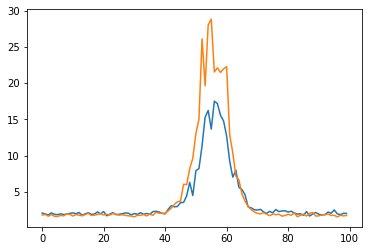

In [160]:
plt.plot(consolidation[0]['rate_avg'].T[consolidation[0]['sorting']][50])
plt.plot(consolidation[1]['rate_avg'].T[consolidation[0]['sorting']][50])

In [16]:
consolidation[0]['rate_avg'][:, 0].max()

19.57364054106693

In [17]:
consolidation[0]['rate_avg'].max(axis=0)

array([19.57364054, 20.35640235, 16.26211125, 21.79895246, 20.16409016,
       22.26924688, 17.19361017, 20.23513092, 20.18162018, 18.40120769,
       19.2458668 , 19.64217877, 20.3713254 , 20.49957128, 19.08038558,
       19.3368535 , 20.59343978, 18.27958446, 21.13096035, 22.0645879 ,
       17.91011063, 19.68603937, 16.83171536, 22.91795393, 20.28577309,
       18.33640436, 17.54750174, 19.50368114, 19.32706563, 18.88690382,
       14.544905  , 22.55337483, 18.88282506, 17.75201592, 20.14885546,
       15.70012899, 20.09366754, 17.64225472, 17.9136767 , 19.69118235,
       19.8604919 , 20.4084886 , 18.36677963, 19.04165502, 19.7059283 ,
       18.65401868, 22.18945618, 20.82402865, 20.02177176, 18.93830142,
       18.77450042, 16.33274695, 19.17568182, 18.75672204, 22.2349301 ,
       21.20507258, 22.23720963, 23.37730892, 19.05082421, 19.61724254,
       18.05344795, 21.41549456, 18.81330997, 19.99692154, 20.43229463,
       20.88190574, 18.57262157, 18.25813434, 19.15499279, 20.53

In [32]:
v_data_amp = np.vstack([consolidation[0]['rate_avg'].max(axis=0), consolidation[1]['rate_avg'].max(axis=0), remapping[1]['rate_avg'].max(axis=0)])

In [49]:
np.argmax(consolidation[0]['rate_avg'][:, 0])

9

In [98]:
place_field_shift_consolidation = np.argmax(consolidation[0]['rate_avg'], axis=0) - np.argmax(consolidation[1]['rate_avg'], axis=0)
place_field_shift_remapping = np.argmax(remapping[0]['rate_avg'], axis=0) - np.argmax(remapping[1]['rate_avg'], axis=0)

v_data_place_filed_shifts = np.vstack([place_field_shift_consolidation, place_field_shift_remapping])
m1 = v_data_place_filed_shifts >= 50
v_data_place_filed_shifts[m1] -= 100
m2 = v_data_place_filed_shifts <= -50
v_data_place_filed_shifts[m2] += 100

In [99]:
v_data_place_fi

NameError: name 'v_data_place_fi' is not defined

In [89]:
v_data_place_filed_shifts 

1

In [96]:
place_field_shift_consolidation

array([ 0,  0,  0,  0,  4, -1,  1,  1,  3,  1,  2,  3,  1,  0,  5,  5,  1,
        0,  2,  0, -1,  1,  4,  3,  3,  3,  6,  1,  4,  0,  2, -2,  0,  6,
        0,  0,  3,  3, -1,  1,  0,  2,  5, 95,  3,  3,  1,  6,  3,  0,  3,
       -1, -1,  6,  0,  1,  4, -2,  6,  3,  3,  2, -1,  2, -2,  1, -1,  6,
        3,  0,  3,  3,  0, -2,  2,  1,  3, 94,  0,  1,  3,  1,  3,  2,  3,
        0,  1,  3,  0,  5,  2,  3,  3,  2,  1,  4, 98,  2,  0,  1])